**Exploratory Data Analysis (EDA) Project Using Python**

**Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Insight**

All essential libraries for data manipulation and visualization are successfully loaded.

**Load the Dataset**

In [3]:
from google.colab import files
uploaded= files.upload()
df =pd.read_csv(list(uploaded.keys())[0])
print(df.head())
df.info()
df.describe()

Saving sales_data.csv to sales_data (1).csv
   Product_ID   Sale_Date Sales_Rep Region  Sales_Amount  Quantity_Sold  \
0        1052  2023-02-03       Bob  North       5053.97             18   
1        1093  2023-04-21       Bob   West       4384.02             17   
2        1015  2023-09-21     David  South       4631.23             30   
3        1072  2023-08-24       Bob  South       2167.94             39   
4        1061  2023-03-24   Charlie   East       3750.20             13   

  Product_Category  Unit_Cost  Unit_Price Customer_Type  Discount  \
0        Furniture     152.75      267.22     Returning      0.09   
1        Furniture    3816.39     4209.44     Returning      0.11   
2             Food     261.56      371.40     Returning      0.20   
3         Clothing    4330.03     4467.75           New      0.02   
4      Electronics     637.37      692.71           New      0.08   

  Payment_Method Sales_Channel Region_and_Sales_Rep  
0           Cash        Online      

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,5019.265230,25.355000,2475.304550,2728.440120,0.15239
std,29.573505,2846.790126,14.159006,1417.872546,1419.399839,0.08720
min,1001.000000,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,9989.040000,49.000000,4995.300000,5442.150000,0.30000


**Insight**

The dataset was loaded successfully, and initial inspection shows structured sales transaction records.

**Data Cleaning & Feature Engineering**

In [4]:
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])

df['Profit'] = (df['Unit_Price'] - df['Unit_Cost']) * df['Quantity_Sold']

df.isnull().sum()

,0
Product_ID,0
Sale_Date,0
Sales_Rep,0
Region,0
Sales_Amount,0
Quantity_Sold,0
Product_Category,0
Unit_Cost,0
Unit_Price,0
Customer_Type,0


**Sales and Profit Distribution Analysis**

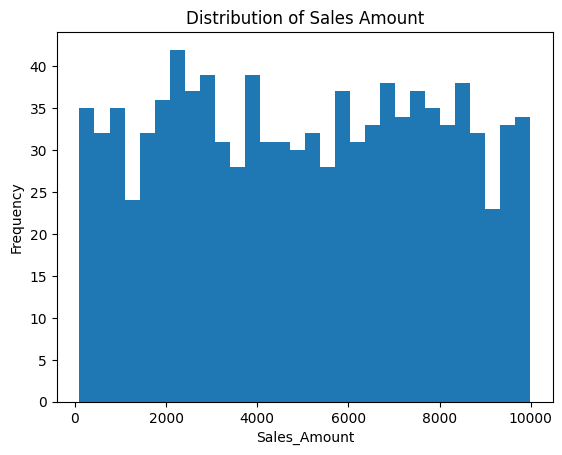

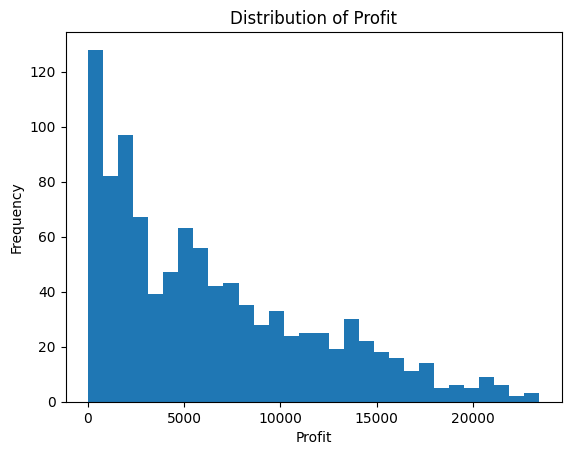

In [5]:
plt.figure()
plt.hist(df['Sales_Amount'], bins=30)
plt.title('Distribution of Sales Amount')
plt.xlabel('Sales_Amount')
plt.ylabel('Frequency')
plt.show()

plt.figure()
plt.hist(df['Profit'], bins=30)
plt.title('Distribution of Profit')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.show()

**Insight**

* Sales are widely distributed.
* Profit shows high variability, including frequent negative values.

**Sales vs Profit Relationship**

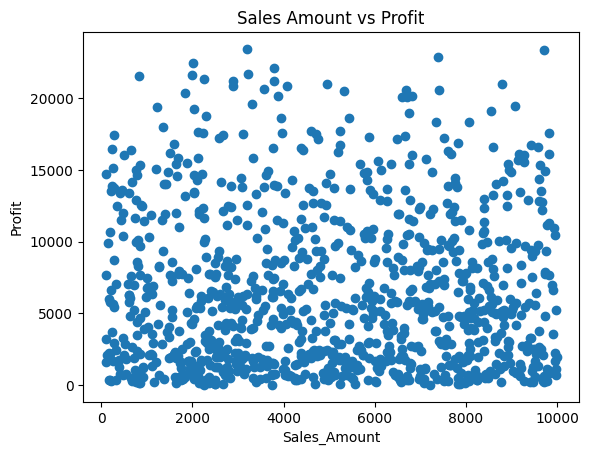

In [6]:
plt.figure()
plt.scatter(df['Sales_Amount'], df['Profit'])
plt.title('Sales Amount vs Profit')
plt.xlabel('Sales_Amount')
plt.ylabel('Profit')
plt.show()

**Insight**

*  Higher sales do not always guarantee higher profit.
* Significant losses occur even at high sales values.

**Regional Performance Analysis**

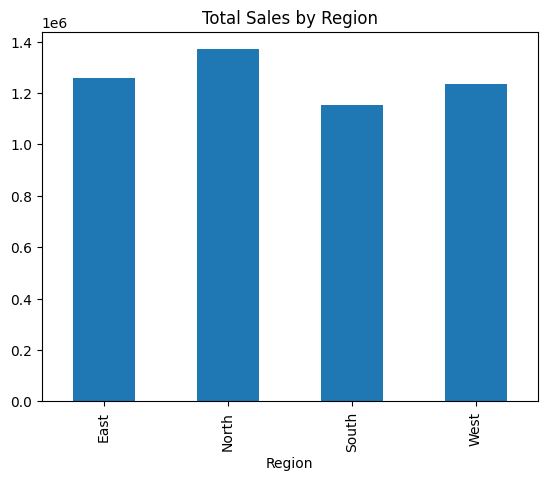

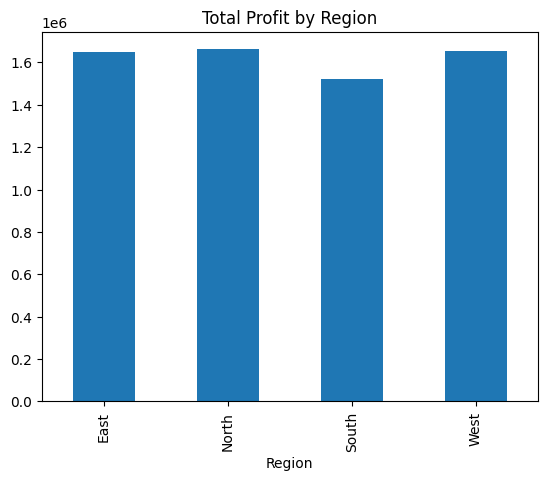

In [7]:
region_sales = df.groupby('Region')['Sales_Amount'].sum()
region_profit = df.groupby('Region')['Profit'].sum()

region_sales.plot(kind='bar', title='Total Sales by Region')
plt.show()

region_profit.plot(kind='bar', title='Total Profit by Region')
plt.show()

**Insight**

* Certain regions generate high sales but low or negative profit.
* Indicates regional cost or discount inefficiencies.

**Product Category Analysis**

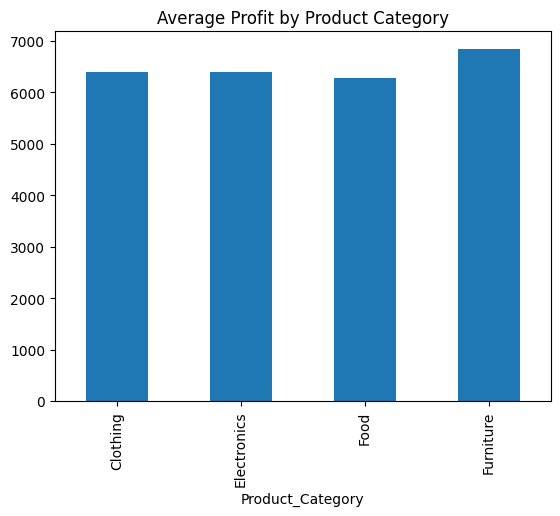

In [8]:
category_profit = df.groupby('Product_Category')['Profit'].mean()
category_profit.plot(kind='bar', title='Average Profit by Product Category')
plt.show()

**Insight**

* Some product categories consistently perform better in terms of profitability.
*  Low-margin categories require pricing or cost optimization.

**Impact of Discount on Profit**

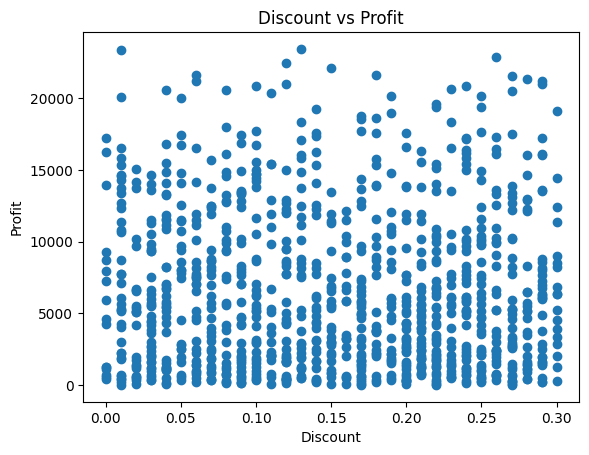

In [9]:
plt.figure()
plt.scatter(df['Discount'], df['Profit'])
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

**Insight**

* Higher discounts are associated with lower profits.
*  Aggressive discounting negatively impacts profitability.

**Sales Channel Performance**

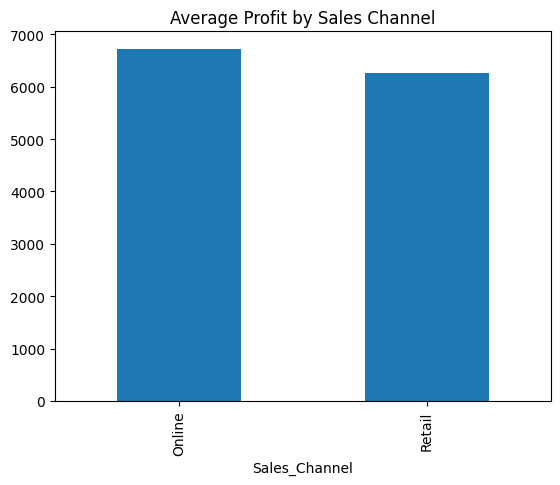

In [10]:
channel_profit = df.groupby('Sales_Channel')['Profit'].mean()
channel_profit.plot(kind='bar', title='Average Profit by Sales Channel')
plt.show()

**Insight**

* Online and Retail channels show different profit behaviors.
* Optimization needed for low-performing channels.

**Key Business Insights**


1. Sales growth alone does not ensure profitability.
2. Discounts and unit costs are major drivers of losses.
3. Certain regions and product categories are consistently underperforming.
4. Strategic pricing and cost control are essential to improve margins.